In [2]:
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

df = pd.read_csv("data/transactions.csv")

print("Shape:", df.shape)
print("\nColumn names:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nFirst 5 rows:")
df.head()

Shape: (1184, 4)

Column names: ['date', 'merchant', 'amount', 'category']

Data types:
 date            str
merchant        str
amount      float64
category        str
dtype: object

Missing values:
 date        0
merchant    0
amount      0
category    0
dtype: int64

First 5 rows:


,date,merchant,amount,category
0,2025-10-28,Naivas Supermarket,1815.65,Food
1,2025-10-28,Java House,834.49,Food
2,2025-10-28,Subway Westgate,2182.54,Food
3,2025-10-28,Naivas Supermarket,1815.65,Food
4,2025-10-28,Subway Westgate,2182.54,Food


In [3]:
df['date'] = pd.to_datetime(df['date'])
df['merchant'] = df['merchant'].str.strip().str.title()
df = df.drop_duplicates()
df = df[df['amount'].notna()]
df = df[df['amount'] > 0]
df['month'] = df['date'].dt.month
df['month_name'] = df['date'].dt.strftime('%B')
df['day_of_week'] = df['date'].dt.day_name()
df['week'] = df['date'].dt.isocalendar().week
print("Clean shape:", df.shape)
print("\nDate range:", df['date'].min(), "to", df['date'].max())
df.head()

Clean shape: (598, 8)

Date range: 2025-10-28 00:00:00 to 2026-04-26 00:00:00


,date,merchant,amount,category,month,month_name,day_of_week,week
0,2025-10-28,Naivas Supermarket,1815.65,Food,10,October,Tuesday,44
1,2025-10-28,Java House,834.49,Food,10,October,Tuesday,44
2,2025-10-28,Subway Westgate,2182.54,Food,10,October,Tuesday,44
6,2025-10-29,Mr Price,4273.41,Shopping,10,October,Wednesday,44
7,2025-10-29,Zara Village Market,5658.92,Shopping,10,October,Wednesday,44


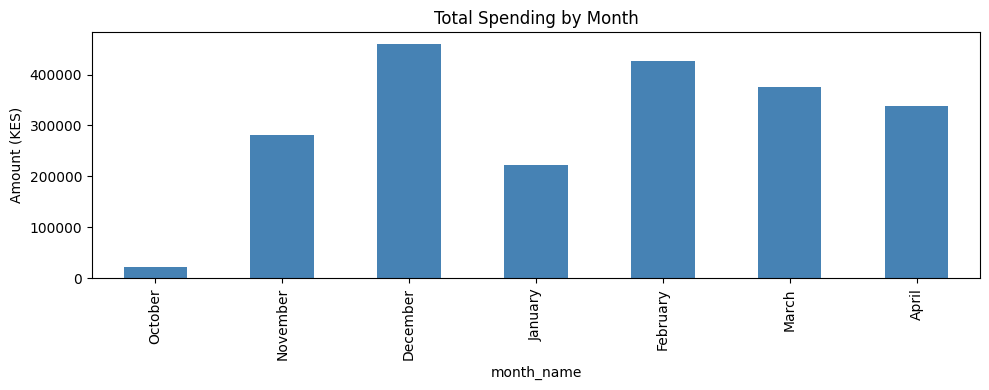

In [4]:
monthly = df.groupby('month_name')['amount'].sum().reindex(
    ['October','November','December','January','February','March','April']
)
monthly.plot(kind='bar', figsize=(10,4), color='steelblue', title='Total Spending by Month')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

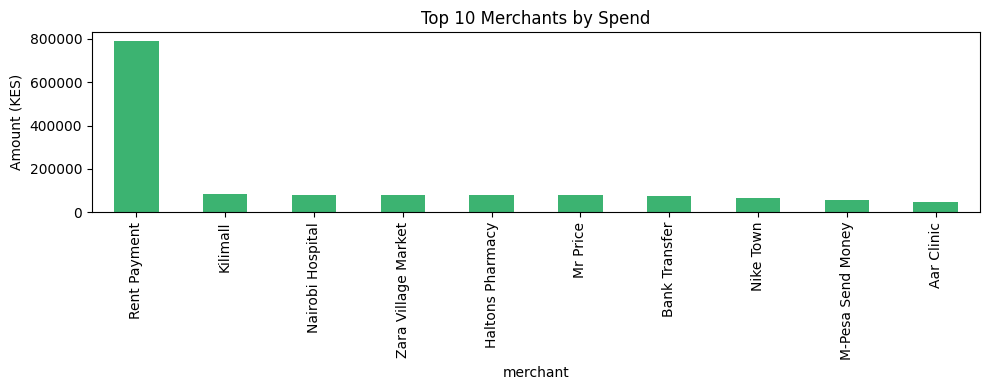

In [5]:
top_merchants = df.groupby('merchant')['amount'].sum().sort_values(ascending=False).head(10)
top_merchants.plot(kind='bar', figsize=(10,4), color='mediumseagreen', title='Top 10 Merchants by Spend')
plt.ylabel('Amount (KES)')
plt.tight_layout()
plt.show()

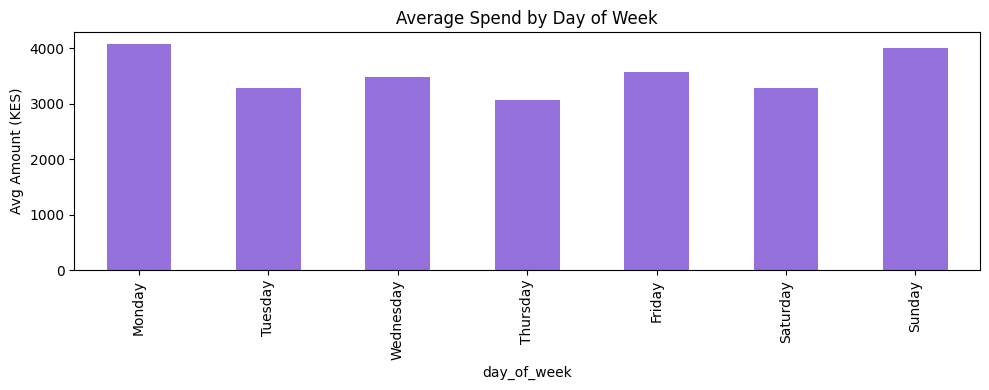

In [6]:
dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
dow_spend = df.groupby('day_of_week')['amount'].mean().reindex(dow_order)
dow_spend.plot(kind='bar', figsize=(10,4), color='mediumpurple', title='Average Spend by Day of Week')
plt.ylabel('Avg Amount (KES)')
plt.tight_layout()
plt.show()

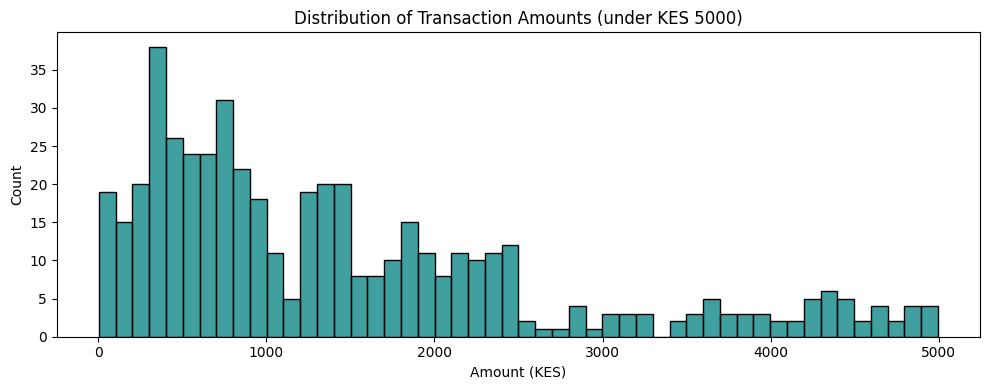

In [7]:
plt.figure(figsize=(10,4))
sns.histplot(df[df['amount'] < 5000]['amount'], bins=50, color='teal')
plt.title('Distribution of Transaction Amounts (under KES 5000)')
plt.xlabel('Amount (KES)')
plt.tight_layout()
plt.show()

In [8]:
df.to_csv("data/cleaned_transactions.csv", index=False)
print(f"Saved {len(df)} clean transactions")

Saved 598 clean transactions
